Dataset directory : ./datasets  (relative to notebook location)
Random state      : 42
Fetching imbalanced-learn datasets (download on first run)...
  [OK] Yeast ME2             n=  1,484  minority=   51  IR=   28.1  -> saved
  [OK] Mammography           n= 11,183  minority=  260  IR=   42.0  -> saved
  [OK] Abalone-19            n=  4,177  minority=   32  IR=  129.5  -> saved
  [OK] Wine Quality          n=  4,898  minority=  183  IR=   25.8  -> saved
  [OK] Ecoli                 n=    336  minority=   35  IR=    8.6  -> saved
  [OK] Protein Homo          n=145,751  minority=1,296  IR=  111.5  -> saved
  [OK] PageBlocks            n=  5,473  minority=   28  IR=  194.5  -> saved
  [OK] Credit Default        n= 30,000  minority=6,636  IR=    3.5  -> saved
  [OK] Credit Card Fraud     n=284,807  minority=  492  IR=  577.9  -> saved
  [OK] IBM HR Attrition      n=  1,470  minority=  237  IR=    5.2  -> saved
  [OK] UNSW-NB15 (reloaded)  n=175,341
  [OK] Pima Diabetes (loaded from cache)
 

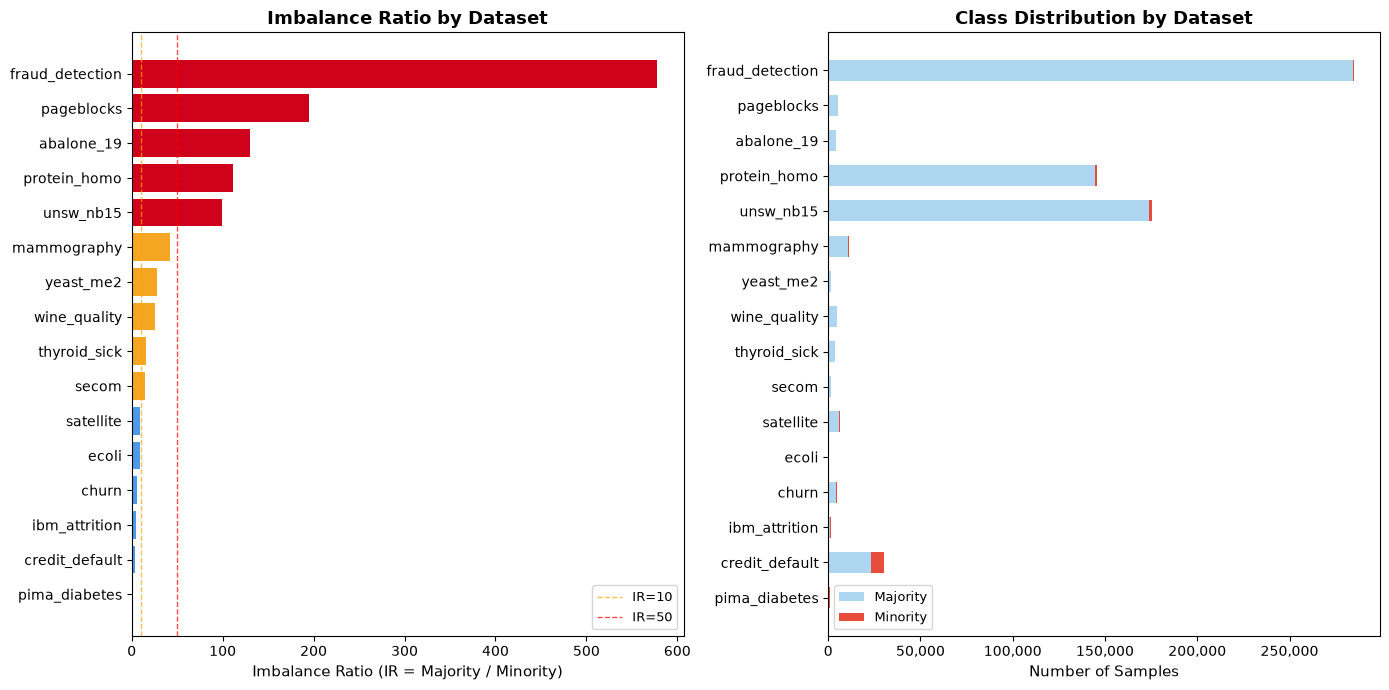

Figure saved -> ./results/01_dataset_summary.png
Verifying saved CSV files...

  [OK] yeast_me2                  shape=(1484, 9)        target_values=[np.int64(0), np.int64(1)]
  [OK] mammography                shape=(11183, 7)       target_values=[np.int64(0), np.int64(1)]
  [OK] abalone_19                 shape=(4177, 11)       target_values=[np.int64(0), np.int64(1)]
  [OK] wine_quality               shape=(4898, 12)       target_values=[np.int64(0), np.int64(1)]
  [OK] ecoli                      shape=(336, 8)         target_values=[np.int64(0), np.int64(1)]
  [OK] protein_homo               shape=(145751, 75)     target_values=[np.int64(0), np.int64(1)]
  [OK] thyroid_sick               shape=(3772, 53)       target_values=[np.int64(0), np.int64(1)]
  [OK] pageblocks                 shape=(5473, 11)       target_values=[np.int64(0), np.int64(1)]
  [OK] satellite                  shape=(6430, 37)       target_values=[np.int64(0), np.int64(1)]
  [OK] churn                      shape

In [3]:
"""
Q-G-CTGAN: Quality-Aware Cluster-Conditioned Oversampling
via Intra-Cluster Synthetic Sample Filtering

Notebook 01: Dataset Loading & Verification

This notebook loads all benchmark datasets used in the Q-G-CTGAN experiments,
including the original 11 datasets from the manuscript and 5 additional
datasets introduced during the major revision (in response to Reviewer #1's
request for recent, large-scale, and domain-diverse imbalanced benchmarks).

Standardized CSV files are saved to ./datasets/ for use in subsequent
notebooks (02_baselines, 03_Q-G-CTGAN, 04_new_baselines, 05_ablation,
06_analysis).
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

# -- Paths --------------------------------------------------
DATASET_DIR = "./datasets"
os.makedirs(DATASET_DIR, exist_ok=True)

# -- Reproducibility -----------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Dataset directory : {DATASET_DIR}  (relative to notebook location)")
print(f"Random state      : {RANDOM_STATE}")


### 1-1. imbalanced-learn built-in datasets

from imblearn.datasets import fetch_datasets

IMBLEARN_TARGETS = {
    "yeast_me2"   : "Yeast ME2",
    "mammography" : "Mammography",
    "abalone_19"  : "Abalone-19",
    "wine_quality": "Wine Quality",
    "ecoli"       : "Ecoli",
    "protein_homo": "Protein Homo",
}

print("Fetching imbalanced-learn datasets (download on first run)...")
all_ds = fetch_datasets()

imblearn_dfs = {}
for key, label in IMBLEARN_TARGETS.items():
    ds = all_ds[key]
    X, y = ds.data, ds.target
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
    df["target"] = (y == 1).astype(int)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, f"{key}.csv")
    df.to_csv(path, index=False)
    imblearn_dfs[key] = df

    print(f"  [OK] {label:<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")


### 1-2. OpenML - PageBlocks

import openml

OPENML_TARGETS = [
    (30, "pageblocks", "PageBlocks"),
]

openml_dfs = {}
for ds_id, key, label in OPENML_TARGETS:
    try:
        dataset = openml.datasets.get_dataset(ds_id)
        X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
        df = X.copy()
        y_s = pd.Series(y).astype(str)
        min_cls = y_s.value_counts().idxmin()
        df["target"] = (y_s == min_cls).astype(int)

        cat_cols = df.select_dtypes(include="object").columns
        if len(cat_cols):
            df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

        minority = int(df["target"].sum())
        majority = len(df) - minority
        ir = round(majority / minority, 2)

        path = os.path.join(DATASET_DIR, f"{key}.csv")
        df.to_csv(path, index=False)
        openml_dfs[key] = df
        print(f"  [OK] {label:<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")

    except Exception as e:
        print(f"  [FAIL] {label}  Error: {e}")


### 1-3. UCI - Default of Credit Card Clients

from ucimlrepo import fetch_ucirepo

uci_dfs = {}
try:
    ds = fetch_ucirepo(id=350)
    X, y = ds.data.features, ds.data.targets
    df = pd.concat([X, y], axis=1)
    df.columns = [*X.columns, "target"]
    df["target"] = df["target"].astype(int)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, "credit_default.csv")
    df.to_csv(path, index=False)
    uci_dfs["credit_default"] = df
    print(f"  [OK] {'Credit Default':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")

except Exception as e:
    print(f"  [FAIL] Credit Default  Error: {e}")
    print("    Manual download: https://archive.ics.uci.edu/dataset/350")


### 1-4. Kaggle - Fraud Detection & IBM HR Attrition (re-run)

DATASET_DIR = "./datasets"
KAGGLE_RAW_DIR = "./kaggle_raw"

KAGGLE_FILES = [
    {
        "key"   : "fraud_detection",
        "label" : "Credit Card Fraud",
        "file"  : "creditcard.csv",
        "target": "Class",
        "encode": False,
    },
    {
        "key"   : "ibm_attrition",
        "label" : "IBM HR Attrition",
        "file"  : "WA_Fn-UseC_-HR-Employee-Attrition.csv",
        "target": "Attrition",
        "encode": True,
    },
]

kaggle_dfs = {}
for cfg in KAGGLE_FILES:
    candidates = [
        os.path.join(DATASET_DIR, cfg["file"]),
        os.path.join(KAGGLE_RAW_DIR, cfg["file"]),
        os.path.join(DATASET_DIR, f"{cfg['key']}.csv"),
    ]
    src = next((p for p in candidates if os.path.exists(p)), None)

    if src is None:
        print(f"  [FAIL] {cfg['label']}  ->  file not found: {cfg['file']}")
        continue

    df = pd.read_csv(src)

    if cfg["encode"]:
        df["target"] = (df[cfg["target"]] == "Yes").astype(int)
        df = df.drop(columns=[cfg["target"]])
        cat_cols = df.select_dtypes(include="object").columns
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    else:
        df = df.rename(columns={cfg["target"]: "target"})

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, f"{cfg['key']}.csv")
    df.to_csv(path, index=False)
    kaggle_dfs[cfg["key"]] = df
    print(f"  [OK] {cfg['label']:<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")

# Also re-attach unsw_nb15 into kaggle_dfs since this dict was just re-created
unsw_path = os.path.join(DATASET_DIR, "unsw_nb15.csv")
if os.path.exists(unsw_path):
    df_unsw = pd.read_csv(unsw_path)
    kaggle_dfs["unsw_nb15"] = df_unsw
    print(f"  [OK] {'UNSW-NB15 (reloaded)':<20}  n={len(df_unsw):>7,}")

### 1-5. Pima Indians Diabetes

pima_dfs = {}
pima_path = os.path.join(DATASET_DIR, "pima_diabetes.csv")

if os.path.exists(pima_path):
    df = pd.read_csv(pima_path)
    if "Outcome" in df.columns:
        df = df.rename(columns={"Outcome": "target"})
    print("  [OK] Pima Diabetes (loaded from cache)")
else:
    try:
        ds = fetch_ucirepo(id=34)
        X, y = ds.data.features, ds.data.targets
        df = pd.concat([X, y], axis=1)
        df.columns = [*X.columns, "target"]
        df["target"] = df["target"].astype(int)
    except Exception:
        url = ("https://raw.githubusercontent.com/"
               "jbrownlee/Datasets/master/pima-indians-diabetes.data.csv")
        cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                "Insulin","BMI","DiabetesPedigreeFunction","Age","target"]
        df = pd.read_csv(url, header=None, names=cols)

minority = int(df["target"].sum())
majority = len(df) - minority
ir = round(majority / minority, 2)

df.to_csv(pima_path, index=False)
pima_dfs["pima_diabetes"] = df
print(f"  [OK] {'Pima Diabetes':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")


### 1-6. OpenML - Satellite (Landsat)
# Added in major revision: addresses Reviewer #1's request for additional
# recent, large-scale benchmarks. Domain: remote sensing.

SATELLITE_ID = 182  # Statlog (Landsat Satellite), OpenML d/182

try:
    dataset = openml.datasets.get_dataset(SATELLITE_ID)
    X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
    df = X.copy()
    y_s = pd.Series(y).astype(str)

    # Minority class = smallest class among the 6 land-cover types
    min_cls = y_s.value_counts().idxmin()
    df["target"] = (y_s == min_cls).astype(int)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, "satellite.csv")
    df.to_csv(path, index=False)
    openml_dfs["satellite"] = df

    print(f"  [OK] {'Satellite':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")
    print(f"       Minority class definition: class {min_cls} (damp grey soil)")

except Exception as e:
    print(f"  [FAIL] Satellite  Error: {e}")


### 1-7. OpenML - Churn (Telecom Customer Churn)
# Added in major revision. Domain: telecommunications.

CHURN_ID = 40701  # "churn" dataset, OpenML d/40701

try:
    dataset = openml.datasets.get_dataset(CHURN_ID)
    X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
    df = X.copy()
    y_s = pd.Series(y).astype(str)

    print(f"Churn raw target distribution:\n{y_s.value_counts()}")

    min_cls = y_s.value_counts().idxmin()
    df["target"] = (y_s == min_cls).astype(int)

    # Encode remaining categoricals if any
    cat_cols = df.select_dtypes(include="object").columns
    if len(cat_cols):
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, "churn.csv")
    df.to_csv(path, index=False)
    openml_dfs["churn"] = df

    print(f"  [OK] {'Churn':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")
    print(f"       Minority class definition: '{min_cls}'")

except Exception as e:
    print(f"  [FAIL] Churn  Error: {e}")


### 1-8. UCI - SECOM (Semiconductor Manufacturing)
# Added in major revision. Domain: semiconductor manufacturing / fault detection.
# NOTE: ucimlrepo does not expose a pre-split target for this dataset
# (target_col metadata is None), so features and target are extracted
# manually from ds.data.original.
# NOTE: This dataset contains missing values by design (sensor read failures),
# which is a realistic characteristic of industrial manufacturing data.
# Missing values are imputed with column-wise median prior to saving, since
# downstream oversampling methods (CTGAN, SMOTE, etc.) require complete data.

SECOM_ID = 179  # UCI ML Repository, SECOM

try:
    ds = fetch_ucirepo(id=SECOM_ID)
    df = ds.data.original.copy()

    print(f"SECOM raw target distribution:\n{df['class'].value_counts()}")
    print(f"Missing values before imputation: {df.drop(columns=['class', 'timestamp']).isna().sum().sum()}")

    # Label encoding: -1 (pass) -> 0, 1 (fail) -> 1
    df["target"] = (df["class"] == 1).astype(int)
    df = df.drop(columns=["class", "timestamp"])

    # Median imputation for missing sensor readings (feature columns only)
    feature_cols = df.columns.drop("target")
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

    # Drop any constant columns (zero variance) left after imputation
    constant_cols = [c for c in feature_cols if df[c].nunique() <= 1]
    if constant_cols:
        df = df.drop(columns=constant_cols)
        print(f"Dropped {len(constant_cols)} constant columns after imputation")

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, "secom.csv")
    df.to_csv(path, index=False)
    uci_dfs["secom"] = df

    print(f"  [OK] {'SECOM':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")

except Exception as e:
    print(f"  [FAIL] SECOM  Error: {e}")


### 1-9. imbalanced-learn - Thyroid Sick (Thyroid Disease)
# Added in major revision. Domain: medical diagnosis (early disease detection).
# NOTE: ucimlrepo does not support import of UCI id=102 (Thyroid Disease);
# the equivalent binary-labeled version is available via imbalanced-learn's
# built-in dataset collection as "thyroid_sick".

try:
    ds = all_ds["thyroid_sick"]
    X, y = ds.data, ds.target
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
    df["target"] = (y == 1).astype(int)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, "thyroid_sick.csv")
    df.to_csv(path, index=False)
    imblearn_dfs["thyroid_sick"] = df

    print(f"  [OK] {'Thyroid Sick':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")

except Exception as e:
    print(f"  [FAIL] Thyroid Sick  Error: {e}")


### 1-10. Kaggle - UNSW-NB15 (Network Intrusion Detection)
# Added in major revision. Domain: cybersecurity / network intrusion detection.
# NOTE: The official UNSW distribution (research.unsw.edu.au) is hosted on a
# SharePoint folder without a stable direct-download URL suitable for
# programmatic access. We therefore use a well-known Kaggle mirror
# (dhoogla/unswnb15) that redistributes the original UNSW-NB15 CSV/parquet
# files under the original authors' academic-use license
# (Moustafa & Slay, 2015).

import kaggle

UNSW_KAGGLE_REF = "dhoogla/unswnb15"
UNSW_RAW_DIR = os.path.join(DATASET_DIR, "raw_unsw")
os.makedirs(UNSW_RAW_DIR, exist_ok=True)

try:
    kaggle.api.dataset_download_files(UNSW_KAGGLE_REF, path=UNSW_RAW_DIR, unzip=True)
    print("Downloaded files:")
    for f in os.listdir(UNSW_RAW_DIR):
        print(f"  - {f}")
except Exception as e:
    print(f"[FAIL] UNSW-NB15 download  Error: {e}")

# Load UNSW-NB15 training set
train_path = os.path.join(UNSW_RAW_DIR, "UNSW_NB15_training-set.parquet")
df_unsw_raw = pd.read_parquet(train_path)

print(f"Shape: {df_unsw_raw.shape}")
print(f"\nAttack category distribution:")
print(df_unsw_raw["attack_cat"].value_counts())

# Binarize UNSW-NB15 - Backdoor detection
# Minority class: "Backdoor" attacks (n=1,746, the second-rarest category).
# The rarest category ("Worms", n=130) yields IR > 1300, which exceeds the
# manuscript's original IR range (1.87-577.88); "Backdoor" keeps the new
# dataset within the extreme-IR tier while remaining consistent with the
# established range.

df = df_unsw_raw.copy()
df["target"] = (df["attack_cat"] == "Backdoor").astype(int)
df = df.drop(columns=["attack_cat", "label"])

# Encode categorical network protocol/service/state columns
cat_cols = df.select_dtypes(include="object").columns
if len(cat_cols):
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

minority = int(df["target"].sum())
majority = len(df) - minority
ir = round(majority / minority, 2)

path = os.path.join(DATASET_DIR, "unsw_nb15.csv")
df.to_csv(path, index=False)
kaggle_dfs["unsw_nb15"] = df

print(f"  [OK] {'UNSW-NB15':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  -> saved")


## 2. Dataset Summary

all_datasets = {}
for d in [imblearn_dfs, openml_dfs, uci_dfs, kaggle_dfs, pima_dfs]:
    all_datasets.update(d)

IR_BINS = {
    "Low (IR < 10)"        : lambda ir: ir < 10,
    "Medium (10 <= IR < 50)": lambda ir: 10 <= ir < 50,
    "High (IR >= 50)"       : lambda ir: ir >= 50,
}

rows = []
for name, df in all_datasets.items():
    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)
    n_features = df.shape[1] - 1
    ir_group = next(k for k, fn in IR_BINS.items() if fn(ir))

    rows.append({
        "Dataset"  : name,
        "Samples"  : len(df),
        "Features" : n_features,
        "Minority" : minority,
        "Majority" : majority,
        "IR"       : ir,
        "IR Group" : ir_group,
    })

summary = pd.DataFrame(rows).sort_values("IR").reset_index(drop=True)
summary.index += 1

print("=" * 75)
print("Dataset Summary")
print("=" * 75)
print(summary.to_string())
print("=" * 75)
print(f"Total datasets loaded: {len(summary)}")
print(f"IR groups  -  {summary['IR Group'].value_counts().to_dict()}")


## 3. Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

colors = {
    "Low (IR < 10)"        : "#4C9BE8",
    "Medium (10 <= IR < 50)": "#F5A623",
    "High (IR >= 50)"       : "#D0021B",
}
bar_colors = [colors[g] for g in summary["IR Group"]]

axes[0].barh(summary["Dataset"], summary["IR"], color=bar_colors)
axes[0].set_xlabel("Imbalance Ratio (IR = Majority / Minority)", fontsize=11)
axes[0].set_title("Imbalance Ratio by Dataset", fontsize=13, fontweight="bold")
axes[0].axvline(10,  color="orange", linestyle="--", linewidth=1, alpha=0.7, label="IR=10")
axes[0].axvline(50,  color="red",    linestyle="--", linewidth=1, alpha=0.7, label="IR=50")
axes[0].legend(fontsize=9)

bar_width = 0.6

axes[1].barh(summary["Dataset"], summary["Majority"],
             color="#AED6F1", label="Majority", height=bar_width)
axes[1].barh(summary["Dataset"], summary["Minority"],
             left=summary["Majority"],
             color="#E74C3C", label="Minority", height=bar_width)
axes[1].set_xlabel("Number of Samples", fontsize=11)
axes[1].set_title("Class Distribution by Dataset", fontsize=13, fontweight="bold")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(fontsize=9)

plt.tight_layout()
os.makedirs("./results", exist_ok=True)
plt.savefig("./results/01_dataset_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> ./results/01_dataset_summary.png")


## 4. Verification

print("Verifying saved CSV files...")
print()

all_ok = True
for name in all_datasets:
    path = os.path.join(DATASET_DIR, f"{name}.csv")
    if os.path.exists(path):
        df_check = pd.read_csv(path)
        assert "target" in df_check.columns, f"'target' column missing in {name}"
        assert df_check["target"].nunique() == 2, f"Non-binary target in {name}"
        print(f"  [OK] {name:<25}  shape={str(df_check.shape):<15}  target_values={sorted(df_check['target'].unique())}")
    else:
        print(f"  [FAIL] {name:<25}  FILE NOT FOUND")
        all_ok = False

print()
if all_ok:
    print("All 16 datasets verified successfully. Ready for experiment notebooks.")
else:
    print("Some datasets are missing. Please re-run the loading cells above.")

In [4]:
results_scaled = pd.read_csv("./results/02_baseline_results_scaled.csv", keep_default_na=False)

fraud_lgbm_none = results_scaled[
    (results_scaled["dataset"] == "fraud_detection") &
    (results_scaled["oversampler"] == "NoOverSampling") &
    (results_scaled["classifier"] == "LGBM")
]
print(fraud_lgbm_none)

             dataset     oversampler classifier  auc_mean   auc_std  \
181  fraud_detection  NoOverSampling       LGBM   0.85909  0.025502   

     time_mean_sec  time_total_sec  
181       0.617801        3.089005  
